# Sales Performance Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading

In [3]:
Data = pd.read_csv("C:\\Users\\deept\\OneDrive\\Pictures\\New folder\\PYTHON\\ProjectFile.csv",encoding="utf-8-sig")
Data

,Row ID,Order ID,Order Date,Customer ID,Customer Name,City,Region,Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,03-01-2020,DP-13000,Darren Powers,Houston,Central,Office Supplies,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2020-112326,04-01-2020,PO-19195,Phillina Ober,Naperville,Central,Office Supplies,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2020-112326,04-01-2020,PO-19195,Phillina Ober,Naperville,Central,Office Supplies,Avery 508,11.784,3,0.2,4.2717
3,4,US-2020-112326,04-01-2020,PO-19195,Phillina Ober,Naperville,Central,Office Supplies,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2020-141817,05-01-2020,MB-18085,Mick Brown,Philadelphia,East,Office Supplies,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,CA-2023-135480,15-12-2023,BG-18435,Bruce Galang,Quebec City,East,Furniture,Hand-Finished Solid Wood Document Frame,68.460,2,0.0,20.5380
9996,9997,CA-2023-135480,15-12-2023,BG-18435,Bruce Galang,Quebec City,East,Office Supplies,Acco Glide Clips,19.600,5,0.0,9.6040
9997,9998,US-2023-137428,16-12-2023,AY-10555,Andy Yotov,Oceanside,West,Furniture,"Global Deluxe Stacking Chair, Gray",81.568,2,0.2,9.1764
9998,9999,US-2023-137428,16-12-2023,AY-10555,Andy Yotov,Oceanside,West,Furniture,"Global Value Steno Chair, Gray",97.184,2,0.2,6.0740


In [4]:
Data["Order Date"] = pd.to_datetime(Data["Order Date"],format="%d-%m-%Y",errors="coerce")

Data["Year"] = Data["Order Date"].dt.year

# Data Inspection

In [5]:
Data.describe()

,Row ID,Order Date,Sales,Quantity,Discount,Profit,Year
count,10000.00000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2022-04-18 00:13:32.160000,229.100822,3.795100,0.155642,28.614510,2021.695300
min,1.00000,2020-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2020.000000
25%,2500.75000,2021-05-03 00:00:00,17.248000,2.000000,0.000000,1.740875,2021.000000
50%,5000.50000,2022-06-12 00:00:00,53.983000,3.000000,0.200000,8.679950,2022.000000
75%,7500.25000,2023-04-26 00:00:00,209.600000,5.000000,0.200000,29.175850,2023.000000
max,10000.00000,2023-12-16 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2023.000000
std,2886.89568,NaN,623.946830,2.229846,0.206137,234.254396,1.122134


In [6]:
Data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Customer ID', 'Customer Name',
       'City', 'Region', 'Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Year'],
      dtype='str')

In [7]:
Data.max()

Row ID                                        10000
Order ID                             US-2023-169999
Order Date                      2023-12-16 00:00:00
Customer ID                                ZD-21925
Customer Name                    Zuschuss Donatelli
City                                           Yuma
Region                                         West
Category                                 Technology
Product Name     netTALK DUO VoIP Telephone Service
Sales                                      22638.48
Quantity                                         14
Discount                                        0.8
Profit                                     8399.976
Year                                           2023
dtype: object

In [8]:
Data.dtypes


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Customer ID                 str
Customer Name               str
City                        str
Region                      str
Category                    str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
dtype: object

In [9]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         10000 non-null  int64         
 1   Order ID       10000 non-null  str           
 2   Order Date     10000 non-null  datetime64[us]
 3   Customer ID    10000 non-null  str           
 4   Customer Name  10000 non-null  str           
 5   City           10000 non-null  str           
 6   Region         10000 non-null  str           
 7   Category       10000 non-null  str           
 8   Product Name   10000 non-null  str           
 9   Sales          10000 non-null  float64       
 10  Quantity       10000 non-null  int64         
 11  Discount       10000 non-null  float64       
 12  Profit         10000 non-null  float64       
 13  Year           10000 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(1), int64(2), str(7)
memory usage: 1.0 MB


In [10]:
Data.shape

(10000, 14)

In [11]:
Data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Customer ID      0
Customer Name    0
City             0
Region           0
Category         0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
dtype: int64

In [12]:
Data.duplicated().sum()

np.int64(0)

In [13]:
Data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Customer ID', 'Customer Name',
       'City', 'Region', 'Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Year'],
      dtype='str')

# KPI Analysis

In [14]:
print(f"Total Sales: {Data['Sales'].sum():,.2f}")

Total Sales: 2,291,008.22


In [15]:
print(f"Total Profit: {Data['Profit'].sum():,.2f}")

Total Profit: 286,145.10


In [16]:
print(f"Total Orders: {Data['Order ID'].nunique()}")

Total Orders: 5007


In [17]:
print(f"Total Customers: {Data['Customer ID'].nunique()}")

Total Customers: 804


# Sales Analysis

In [18]:
# Sales by Region
Data.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       728750.0955
East       683528.3520
Central    496479.6280
South      382250.1470
Name: Sales, dtype: float64

In [19]:
# Sales by Category
Data.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         832718.6930
Furniture          742632.3295
Office Supplies    715657.2000
Name: Sales, dtype: float64

In [20]:
# Top 10 Products by Sales
Data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Lexmark MX611dhe Monochrome Laser Printer                                      16829.901
Name: Sales, dtype: float64

# Data Visualisation

In [21]:
region_sales = (
    Data.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       728750.0955
East       683528.3520
Central    496479.6280
South      382250.1470
Name: Sales, dtype: float64


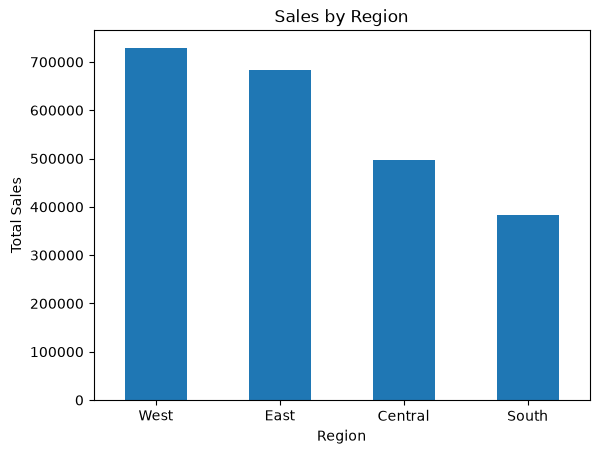

In [22]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [23]:
category_sales = (
    Data.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         832718.6930
Furniture          742632.3295
Office Supplies    715657.2000
Name: Sales, dtype: float64


In [24]:
top_products = (
    Data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Lexmark MX611dhe Monochrome Laser Printer                                      16829.901
Name: Sales, dtype: float64


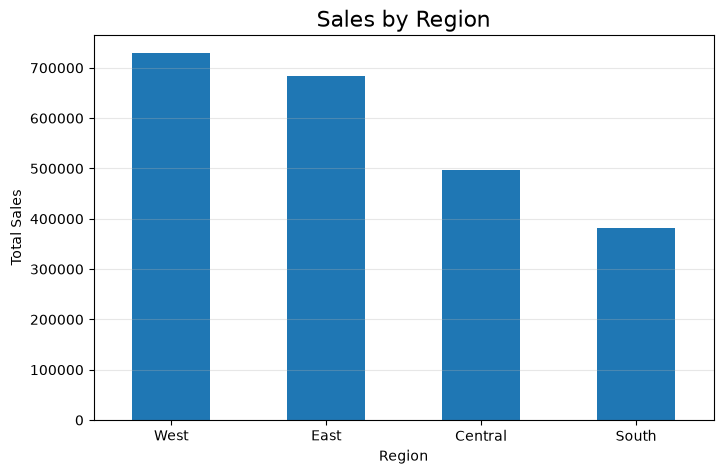

In [25]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

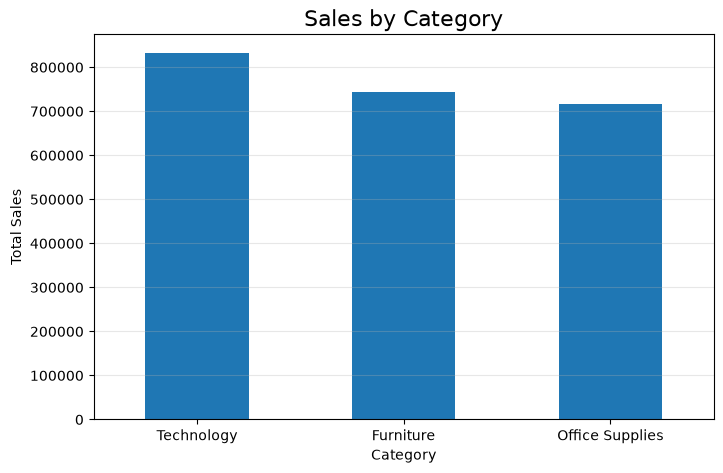

In [26]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

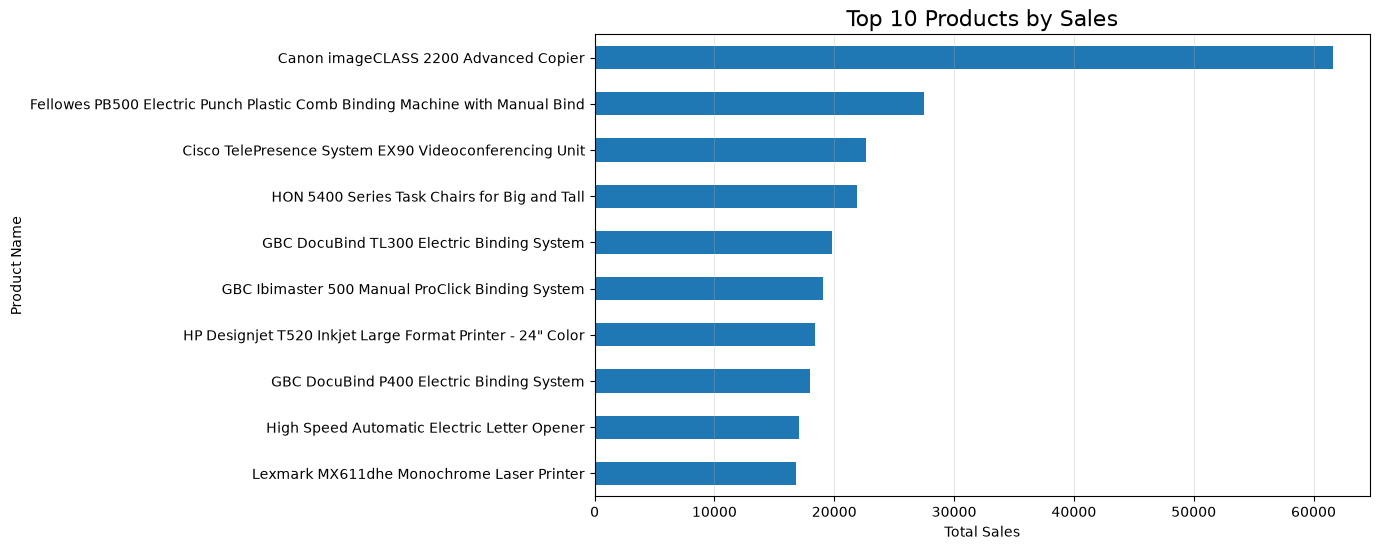

In [27]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(axis="x", alpha=0.3)

plt.show()

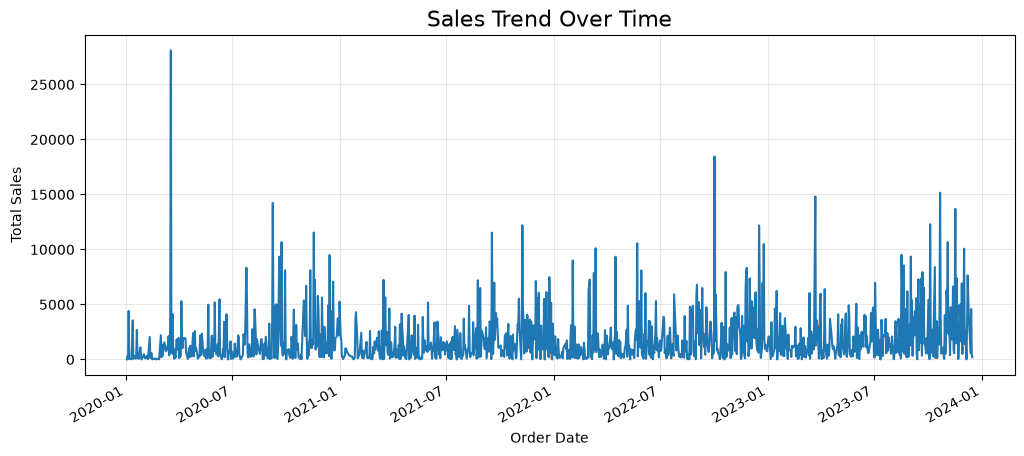

In [28]:
monthly_sales = (
    Data.groupby("Order Date")["Sales"]
    .sum()
)

plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Sales Trend Over Time", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)

plt.show()

In [29]:
Data["Order Date"]=pd.to_datetime(Data["Order Date"],errors="coerce")

In [30]:
monthly_sales = (
    Data.groupby(Data["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

print(monthly_sales)

Order Date
2020-01     14518.0550
2020-02      4519.8920
2020-03     56933.9090
2020-04     28295.3450
2020-05     26319.7670
2020-06     34669.4796
2020-07     33946.3930
2020-08     28918.3385
2020-09     82670.4288
2020-10     32413.3390
2020-11     78826.9567
2020-12     72008.3085
2021-01     18461.9156
2021-02     11951.4110
2021-03     39978.6280
2021-04     34195.2085
2021-05     30246.9465
2021-06     24797.2920
2021-07     28765.3250
2021-08     37057.0042
2021-09     64627.0460
2021-10     31407.1335
2021-11     75972.5635
2021-12     75532.5572
2022-01     18830.3310
2022-02     22978.8150
2022-03     53031.0690
2022-04     38829.1590
2022-05     57042.8380
2022-06     40937.1480
2022-07     40300.4990
2022-08     31716.8143
2022-09     73521.6629
2022-10     59831.0010
2022-11     79411.9658
2022-12     97502.2770
2023-01     44259.2140
2023-02     20301.1334
2023-03     60728.4808
2023-04     36779.0361
2023-05     45155.4822
2023-06     53056.0777
2023-07     45989.4960


In [31]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print(f"Highest Sales Month: {highest_month} - ${highest_sales:,.2f}")
print(f"Lowest Sales Month: {lowest_month} - ${lowest_sales:,.2f}")

Highest Sales Month: 2023-11 - $118,454.51
Lowest Sales Month: 2020-02 - $4,519.89


In [32]:
region_profit = (
    Data.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

Region
West       108767.2986
East        93309.6355
South       45126.9196
Central     38941.2502
Name: Profit, dtype: float64


In [33]:
category_profit = (
    Data.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         144483.3570
Office Supplies    123103.7283
Furniture           18558.0186
Name: Profit, dtype: float64


In [34]:
top_profit_products = (
    Data.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            5975.9004
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [35]:
furniture_analysis = Data[Data["Category"] == "Furniture"].groupby(
    "Sub-Category"
)[["Sales", "Profit", "Discount"]].sum()

print(furniture_analysis)

KeyError: 'Sub-Category'

In [ ]:
furniture_analysis = Data[Data["Category"] == "Furniture"].groupby(
    "Sub-Category"
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean")
)

print(furniture_analysis)

                    Sales      Profit  Avg_Discount
Sub-Category                                       
Bookcases     114324.4005  -3491.8996      0.214027
Chairs        328126.0770  25867.5152      0.171290
Furnishings    94571.5560  13613.7367      0.138625
Tables        205610.2960 -17431.3337      0.258100


In [ ]:
discount_profit = (
    Data.groupby("Discount")["Profit"]
    .sum()
    .sort_index()
)

print(discount_profit)

Discount
0.00    321209.2028
0.10      8912.0862
0.15      1431.6797
0.20     89533.4248
0.30    -10510.2064
0.32     -2379.5417
0.40    -22791.2559
0.45     -2493.1111
0.50    -20364.1411
0.60     -6160.5508
0.70    -40095.5791
0.80    -30146.9035
Name: Profit, dtype: float64


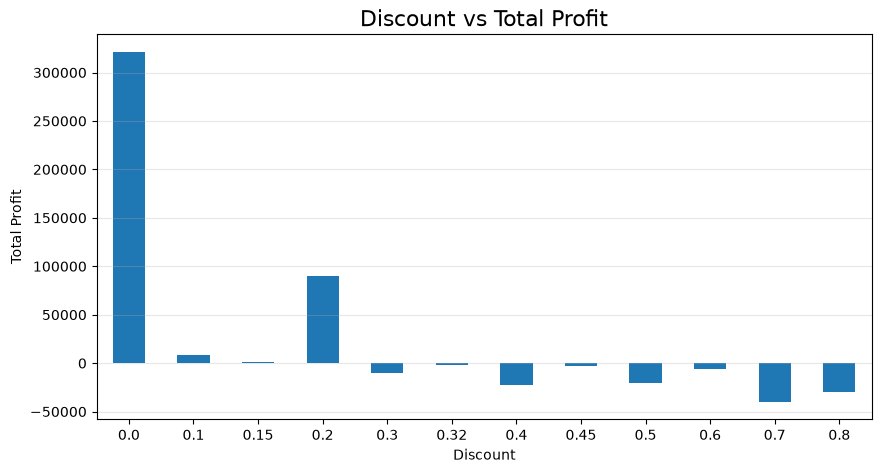

In [ ]:
plt.figure(figsize=(10, 5))

discount_profit.plot(kind="bar")

plt.title("Discount vs Total Profit", fontsize=16)
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
category_summary = Data.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

category_summary["Profit Margin %"] = (
    category_summary["Profit"] / category_summary["Sales"] * 100
)

print(category_summary)

                       Sales       Profit  Profit Margin %
Category                                                  
Furniture        742632.3295   18558.0186         2.498951
Office Supplies  715657.2000  123103.7283        17.201494
Technology       832718.6930  144483.3570        17.350800


In [ ]:
segment_sales = (
    Data.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.148733e+06
Corporate      7.075893e+05
Home Office    4.346855e+05
Name: Sales, dtype: float64


In [ ]:
segment_profit = (
    Data.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_profit)

Segment
Consumer       133592.3766
Corporate       92549.7948
Home Office     60002.9325
Name: Profit, dtype: float64


In [ ]:
segment_summary = Data.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

segment_summary["Profit Margin %"] = (
    segment_summary["Profit"] / segment_summary["Sales"] * 100
)

print(segment_summary)

                    Sales       Profit  Profit Margin %
Segment                                                
Consumer     1.148733e+06  133592.3766        11.629537
Corporate    7.075893e+05   92549.7948        13.079592
Home Office  4.346855e+05   60002.9325        13.803758


In [ ]:
yearly_summary = Data.groupby("Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

yearly_summary["Profit Margin %"] = (
    yearly_summary["Profit"] / yearly_summary["Sales"] * 100
)

print(yearly_summary)

              Sales      Profit  Profit Margin %
Year                                            
2020.0  181524.2337  19424.6821        10.700875
2021.0  165084.9327  19807.9234        11.998626
2022.0  274255.6229  45098.3725        16.443919
2023.0  280662.1303  27334.3301         9.739230


In [ ]:
Data.to_csv("cleaned_sales_data.csv", index=False)